# Pertanyaan Bisnis
**Proyek Capstone:** Perancangan Sistem Prediksi Burnout (CC26-PRU473)

**Pertanyaan 1:**
*"Berdasarkan dataset yang telah ditransformasi untuk konteks general
population, faktor kesehatan universal manakah (seperti jam aktivitas
harian, kualitas tidur, dan aktivitas fisik) yang memiliki korelasi
tertinggi terhadap tingkat burnout, yang dianalisis pada minggu kedua
proyek?"*


---

**Pertanyaan 2:**
*Apakah terdapat perbedaan signifikan rata-rata stress score antara kelompok usia remaja, muda, dewasa, dan tua pada populasi umum, serta kelompok usia mana yang paling rentan mengalami burnout berdasarkan analisis statistik dataset pada minggu kedua proyek?*




## Data Dictionary

| Kolom | Deskripsi |
|--------|------------|
| **age** | Usia developer (tahun). |
| **experience_years** | Pengalaman Koding (tahun). |
| **daily_work_hours** | Jumlah jam kerja per hari. |
| **sleep_hours** | Rata-rata durasi tidur per hari (jam). |
| **caffeine_intake** | Jumlah konsumsi kafein per hari (cangkir). |
| **bugs_per_day** | Jumlah bug yang dihasilkan atau ditemukan per hari. |
| **commits_per_day** | Jumlah commit Git yang dilakukan per hari. |
| **meetings_per_day** | Jumlah meeting yang dihadiri per hari. |
| **screen_time** | Total waktu penggunaan layar per hari (jam). |
| **exercise_hours** | Durasi aktivitas fisik atau olahraga per hari (jam). |
| **stress_level** | Skor tingkat stres asli pada rentang 0–100. |
| **burnout_level** | Label target asli yang menunjukkan tingkat burnout individu. |
| **stress_score** | Skor stres hasil perhitungan atau rekayasa fitur berdasarkan kombinasi beberapa indikator kesehatan dan aktivitas pengguna. (baru) |
| **burnout_general** | Kategori burnout hasil klasifikasi berbasis aturan (*rule-based*) yang dikelompokkan menjadi **Low**, **Medium**, dan **High** berdasarkan nilai *stress_score* .(baru) |

# Importing Libraries

In [72]:
import os
import numpy as np
import pandas as pd
import kagglehub
from google.colab import files
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

# Data Wrangling

## Gathering Data

In [73]:
# 1. Download dataset
path = kagglehub.dataset_download("asifxzaman/developer-burnout-prediction-dataset7000-samples")

# 2. Cek isi folder untuk mengetahui nama file CSV-nya
files = os.listdir(path)
print("Daftar file:", files)

# 3. Baca data
df = pd.read_csv(f"{path}/{files[0]}")


Using Colab cache for faster access to the 'developer-burnout-prediction-dataset7000-samples' dataset.
Daftar file: ['developer_burnout_dataset_7000.csv']


In [74]:
df.head(10)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
5,40.0,2.0,10.25,6.78,0.0,19.0,27.0,4.0,15.15,0.78,51.06,Medium
6,26.0,NaN,6.53,7.60,6.0,4.0,11.0,9.0,9.38,0.54,39.09,Medium
7,38.0,0.0,10.69,5.25,5.0,12.0,2.0,2.0,14.58,0.10,77.68,High
8,42.0,18.0,11.47,4.79,4.0,11.0,25.0,1.0,14.54,1.53,73.56,High
9,30.0,17.0,13.16,5.39,3.0,0.0,3.0,3.0,14.44,0.58,46.78,Medium


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


Berdasarkan output dari `df.info()`, berikut adalah gambaran umum mengenai struktur, tipe data, serta kualitas awal dari dataset prediksi burnout:

* **Dimensi Dataset:** Dataset ini memiliki total **7.000 baris data** (indeks 0 hingga 6999) dan **12 kolom** fitur.
* **Deteksi Nilai yang Hilang (*Missing Values*):** * Ini adalah poin paling krusial. Total baris data adalah 7.000, tetapi **seluruh kolom** (dari `age` hingga `burnout_level`) hanya memiliki **6.860 baris non-null**.
    * Artinya, terdapat **140 baris data kosong (*missing values*)** yang tersebar secara konsisten di setiap kolom (7.000 - 6.860 = 140).
    * *Rekomendasi Tindakan:* Kita perlu menangani 140 data kosong ini pada tahap *Data Cleaning*, baik dengan cara menghapus baris tersebut (*drop*) atau melakukan imputasi (mengisi nilai kosong dengan mean/median) sebelum data dimasukkan ke dalam model.
* **Analisis Tipe Data (*Data Types*):**
    * **Fitur Numerik:** Terdapat 11 kolom yang bertipe data `float64` (angka desimal).
    * **Fitur Target:** Kolom `burnout_level` bertipe `object` (kategorikal/teks). Karena model machine learning hanya menerima input angka, kolom target ini nantinya harus ditransformasikan (misalnya menggunakan *Label Encoding* atau *Mapping* jika nilainya berupa tingkatan seperti Low, Medium, High).
* **Penggunaan Memori:** Dataset ini relatif ringan dengan penggunaan memori sekitar `656.4+ KB`.

## Assessing Data

Identifikasi masalah

In [76]:
df.describe(include='all')


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3485
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825,NaN
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656,NaN
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000,NaN
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500,NaN
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000,NaN
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000,NaN


Berdasarkan ringkasan statistik dari `df.describe(include='all')`, kita dapat membedah karakteristik demografi, kebiasaan kerja, kesehatan, serta tingkat stres dari 6.860 data developer yang tercatat:

#### A. Analisis Fitur Kategorikal (Target)
* **Kolom `burnout_level`:**
  * Memiliki **3 kategori unik** (misalnya: *Low, Medium, High*).
  * Kategori yang paling sering muncul (*top*) adalah **Medium** dengan frekuensi sebanyak **3.485 kali**. Ini berarti lebih dari 50% developer dalam dataset ini berada pada fase tingkat kejenuhan menengah.

#### B. Demografi dan Pengalaman Kerja
* **Usia (`age`):** Rata-rata usia developer adalah **32 tahun** (*mean* = 32.12), dengan rentang usia yang cukup produktif antara **20 tahun (min)** hingga **44 tahun (max)**.
* **Pengalaman Koding (`experience_years`):** Rata-rata pengalaman kerja adalah sekitar **9-10 tahun** (*mean* = 9.58). Menariknya, dataset ini mencakup *fresh graduate* atau pemula dengan pengalaman **0 tahun**, hingga senior dengan pengalaman maksimal **19 tahun**.

#### C. Pola Kerja Harian & Produktivitas
* **Jam Kerja (`daily_work_hours`):** Rata-rata developer bekerja selama **9 jam per hari** (sedikit di atas standar normal 8 jam). Namun, nilai maksimumnya mencapai **14 jam per hari**, yang mengindikasikan adanya kelompok developer yang melakukan lembur ekstrem.
* **Waktu Layar (`screen_time`):** Rata-rata waktu di depan layar sangat tinggi, yaitu **11.97 jam per hari**, dengan nilai maksimal menyentuh **18.93 jam**. Ini sejalan dengan tingginya jam kerja dan aktivitas koding.
* **Aktivitas Git & Koordinasi:** * Rata-rata melakukan **14 kali commit** (`commits_per_day`) dan menghasilkan/menemukan sekitar **9-10 bugs** (`bugs_per_day`) setiap harinya.
  * Developer menghadiri rata-rata **4 sampai 5 kali meeting per hari** (`meetings_per_day`), dengan intensitas tertinggi hingga **9 kali meeting** sehari.

#### D. Pola Kesehatan & Gaya Hidup
* **Waktu Tidur (`sleep_hours`):** Durasi tidur rata-rata berada di angka **6.48 jam per hari**. Sesuai nilai minimumnya, terdapat developer yang hanya tidur **4 jam**, yang tentu saja kurang ideal untuk kesehatan jangka panjang.
* **Konsumsi Kafein (`caffeine_intake`):** Rata-rata konsumsi kafein adalah **3.5 cangkir per hari**, dengan batas maksimal mencapai **7 cangkir harian**. Angka ini menunjukkan ketergantungan yang cukup tinggi pada kafein untuk menjaga fokus.
* **Olahraga (`exercise_hours`):** Aktivitas fisik tergolong sangat minim. Rata-rata developer hanya berolahraga selama **1 jam per hari** (*mean* = 1.00), bahkan 25% dari total data (kuartil 25%) mencatat waktu olahraga di bawah **0.51 jam (sekitar 30 menit)**.

#### E. Indikator Stres
* **Skor Stres (`stress_level`):** Tingkat stres asli memiliki rata-rata nilai **53.65** (dari skala 0-100). Namun, nilai standar deviasinya cukup besar (`std` = 23.44) dan nilai maksimum mencapai **100**, yang berarti variasi tingkat stres antar developer sangat tinggi, dan ada kelompok yang mengalami stres total/maksimal.

---

### Temuan Awal untuk Kebutuhan Model (Prediksi Burnout):
1. **Korelasi Potensial:** Fitur seperti `daily_work_hours` yang tinggi (hingga 14 jam), `screen_time` yang ekstrem (hingga 18.93 jam), dikombinasikan dengan kurang tidur (`sleep_hours` min 4 jam) dan tingginya `stress_level` tampaknya akan menjadi indikator kuat (*strong predictors*) yang memicu label target `burnout_level` menjadi *High*.
2. **Distribusi Data:** Nilai rata-rata (*mean*) dan median (*50%*) pada hampir semua kolom numerik (seperti `age` berpasangan di 32, `daily_work_hours` di 9.00 dan 8.99) memiliki angka yang sangat berdekatan. Ini menandakan bahwa **distribusi data numerik cenderung normal** (*normally distributed*) dan minim dari *outlier* yang merusak.

In [77]:
# Mengecek data yang hilang
df.isnull().sum()

,0
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


In [78]:
#Cek duplicate data
df.duplicated().sum()

np.int64(0)

Hasil 0 menunjukkan bahwa tidak ada satu pun baris data yang duplikat di dalam dataset ini

In [79]:
#Mengecek kolom data yang dianggap kurang relevan untuk general population dan berencana akan di drop
kolom_kandidat = ['bugs_per_day', 'meetings_per_day', 'commits_per_day','experience_years']
df[kolom_kandidat + ['stress_level']].corr()

,bugs_per_day,meetings_per_day,commits_per_day,experience_years,stress_level
bugs_per_day,1.000000,0.014707,0.003480,-0.003547,0.492421
meetings_per_day,0.014707,1.000000,0.016669,0.003572,0.351155
commits_per_day,0.003480,0.016669,1.000000,-0.008876,-0.007626
experience_years,-0.003547,0.003572,-0.008876,1.000000,-0.019935
stress_level,0.492421,0.351155,-0.007626,-0.019935,1.000000


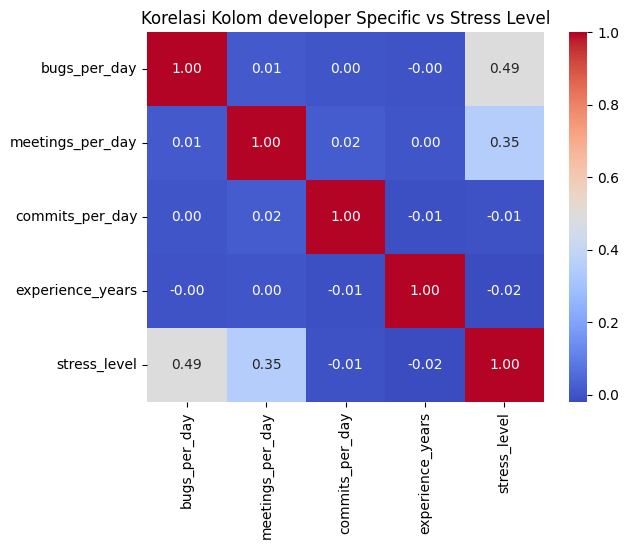

In [80]:
# Bentuk visualisasi atas korelasi kolom data dan label data
kolom_kandidat = ['bugs_per_day', 'meetings_per_day', 'commits_per_day', 'experience_years','stress_level']
corr_matrix = df[kolom_kandidat].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Kolom developer Specific vs Stress Level')
plt.show()

Walaupun beberapa kolom data memiliki korelasi yang cukup kuat, penggunaan
dataset ini akan kurang relevan jika digunakan sebagai burnout detector untuk
general population, karena fitur-fitur tersebut bersifat eksklusif terhadap
profesi software developer. Selain itu, kolom stress_level pada dataset ini
kemungkinan besar juga terbentuk dari fitur-fitur developer-specific tersebut,
sehingga tidak dapat merepresentasikan tingkat stress populasi umum. Oleh karena itu kita akan melakukan drop kolom di tahap cleaning


Oleh karena itu, pada tahap berikutnya akan direncanakan:
1. Drop kolom developer-specific (bugs_per_day, commits_per_day,
   meetings_per_day, experience_years, stress_level)
2. Membuat label burnout baru (burnout_general) berdasarkan
   indikator universal yang didukung literatur ilmiah.
   

# Cleaning

In [81]:
#drop semua kolom yang tidak relevan bersama dengan derived kolom untuk deteksi anomali dan mengganti daily_work_hours menjadi daily_activity_hours
drop_kolom = ['bugs_per_day', 'commits_per_day', 'meetings_per_day','stress_level','burnout_level','start_coding_age','experience_years']
df_clean = df.drop(columns=drop_kolom ,errors='ignore')
df_clean = df_clean.rename(columns={'daily_work_hours': 'daily_activity_hours'})
df_clean.head()


,age,daily_activity_hours,sleep_hours,caffeine_intake,screen_time,exercise_hours
0,26.0,10.33,4.45,2.0,15.07,0.14
1,39.0,8.62,5.77,5.0,13.25,0.54
2,34.0,NaN,4.03,5.0,11.18,1.54
3,30.0,6.85,6.47,2.0,11.14,0.96
4,27.0,4.24,5.80,NaN,8.05,0.36


In [82]:
# Menghapus semua baris yang mengandung NaN
df_clean = df_clean.dropna()

Berdasarkan hasil pemeriksaan df.info() sebelumnya, kita tahu bahwa terdapat baris data yang kosong di semua kolom.Maka kami mengeksekusi .dropna(), untuk menghapus baris tersebut. Langkah ini wajib dilakukan karena algoritma machine learning tidak dapat memproses data yang bernilai NaN.

In [83]:
df_clean.isnull().sum()

,0
age,0
daily_activity_hours,0
sleep_hours,0
caffeine_intake,0
screen_time,0
exercise_hours,0


In [84]:
#Membuat label data baru untuk mengukur faktor stress menurut literatur ilmiah
def calculate_stress_score(row):
    score = 0

    if row['daily_activity_hours'] > 11: score += 2
    if row['sleep_hours'] < 7: score += 2
    if row['exercise_hours'] < 0.5: score += 1
    if row['caffeine_intake'] > 4: score += 1
    if row['screen_time'] > 10:score += 1
    return score

def score_to_burnout(score):
    if score <= 2: return 'Low'
    elif score <= 5:return 'Medium'
    else:return 'High'

df_clean['stress_score']    = df_clean.apply(calculate_stress_score, axis=1)
df_clean['burnout_general'] = df_clean['stress_score'].apply(score_to_burnout)

print("Distribusi Burnout General (Rule-Based):")
print(df_clean['burnout_general'].value_counts())
print(f"\nRange stress_score: {df_clean['stress_score'].min()} - {df_clean['stress_score'].max()}")
print(f"\nKolom df_clean sekarang: {list(df_clean.columns)}")

Distribusi Burnout General (Rule-Based):
burnout_general
Medium    3471
Low       2164
High       566
Name: count, dtype: int64

Range stress_score: 0 - 7

Kolom df_clean sekarang: ['age', 'daily_activity_hours', 'sleep_hours', 'caffeine_intake', 'screen_time', 'exercise_hours', 'stress_score', 'burnout_general']


Dikarenakan label data yang kemungkinan sudah terpapar dengan kolom yang developer specific kami mengambil keputusan untuk membuat label baru nanti menggunakan stress_score baru yang sudah dihitung dengan bantuan beberapa literatur yang membahas threshold seseorang sebelum mengalami stress

In [85]:
import google.colab.files

df_clean.to_csv("df.csv", index=False)
google.colab.files.download("df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exploratory Data Analysis (EDA)

In [86]:
#Cek range tiap fitur data
for col in df_clean.select_dtypes(include='number').columns:
    print(f"{col}: {df_clean[col].min()} - {df_clean[col].max()}")

age: 20.0 - 44.0
daily_activity_hours: 4.0 - 14.0
sleep_hours: 4.0 - 9.0
caffeine_intake: 0.0 - 7.0
screen_time: 5.21 - 18.93
exercise_hours: 0.0 - 2.0
stress_score: 0 - 7


Berdasarkan output yang dihasilkan, kita dapat memvalidasi kelayakan data (data sanity check) untuk memastikan tidak ada nilai yang mustahil secara logika seperti nilai minus atau angka yang terlampau ekstrem:

* age (20.0 - 44.0 tahun): Menunjukkan bahwa subjek penelitian berada di usia produktif kerja. Tidak ada keanehan seperti usia di bawah umur atau usia ratusan tahun.

* daily_activity_hours (4.0 - 14.0 jam): Rentang kerja harian berkisar dari paruh waktu/ringan (4 jam) hingga lembur yang sangat berat (14 jam).

* sleep_hours (4.0 - 9.0 jam): Batas bawah 4 jam tidur mengonfirmasi adanya risiko kurang tidur akut pada beberapa developer, sementara batas atas 9 jam berada di rentang tidur ideal yang sehat.

* caffeine_intake (0.0 - 7.0 cangkir): Ada developer yang tidak mengonsumsi kafein sama sekali (0 cangkir) dan ada yang mengonsumsi hingga 7 cangkir sehari. Konsumsi 7 cangkir merupakan angka yang cukup tinggi dan berpotensi memengaruhi tingkat stres atau gangguan tidur.

* screen_time (5.21 - 18.93 jam): Waktu di depan layar maksimal menyentuh 18.93 jam, yang berarti hampir seluruh waktu bangun developer tersebut dihabiskan menatap layar komputer/gawai. Ini merupakan salah satu indikator fisik terkuat yang memicu kelelahan visual dan mental (burnout).

* exercise_hours (0.0 - 2.0 jam): Waktu olahraga maksimal hanya 2 jam.

* stress_score (0 - 7): Skor stres hasil rekayasa fitur memiliki skala dengan rentang antara nilai 0 hingga 7.

/tmp/ipykernel_1515/2572813182.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='burnout_general', y='daily_activity_hours',
/tmp/ipykernel_1515/2572813182.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='burnout_general', y='sleep_hours',
/tmp/ipykernel_1515/2572813182.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='burnout_general', y='exercise_hours',
/tmp/ipykernel_1515/2572813182.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be re

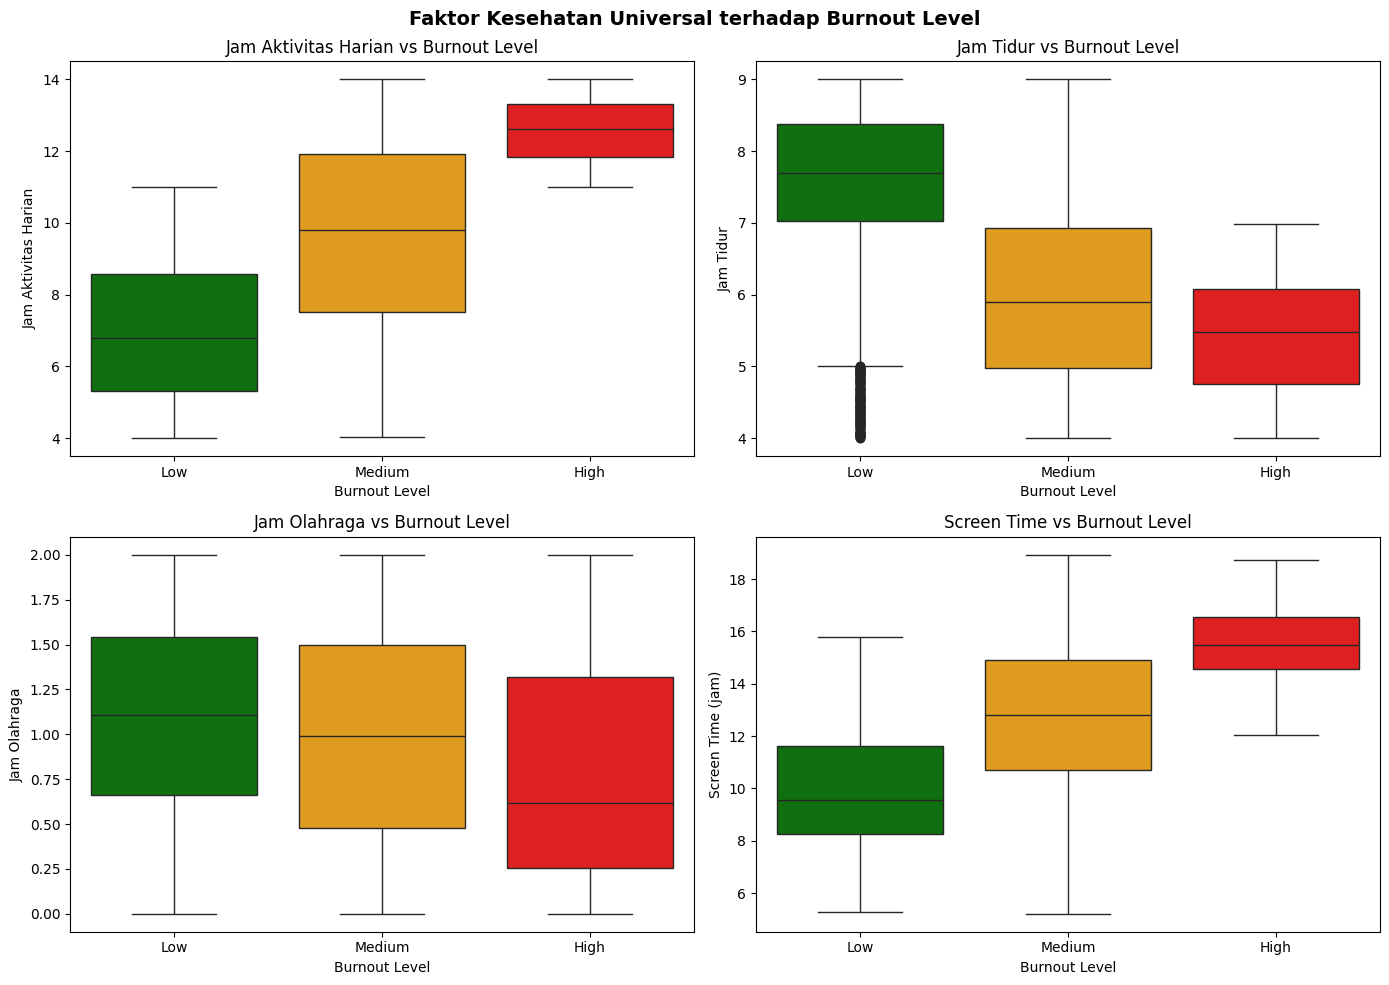

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Faktor Kesehatan Universal terhadap Burnout Level',
             fontsize=14, fontweight='bold')

palette = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
order   = ['Low', 'Medium', 'High']

# 1. Jam Aktivitas vs Burnout
sns.boxplot(data=df_clean, x='burnout_general', y='daily_activity_hours',
            order=order, palette=palette, ax=axes[0,0])
axes[0,0].set_title('Jam Aktivitas Harian vs Burnout Level')
axes[0,0].set_xlabel('Burnout Level')
axes[0,0].set_ylabel('Jam Aktivitas Harian')

# 2. Jam Tidur vs Burnout
sns.boxplot(data=df_clean, x='burnout_general', y='sleep_hours',
            order=order, palette=palette, ax=axes[0,1])
axes[0,1].set_title('Jam Tidur vs Burnout Level')
axes[0,1].set_xlabel('Burnout Level')
axes[0,1].set_ylabel('Jam Tidur')

# 3. Jam Olahraga vs Burnout
sns.boxplot(data=df_clean, x='burnout_general', y='exercise_hours',
            order=order, palette=palette, ax=axes[1,0])
axes[1,0].set_title('Jam Olahraga vs Burnout Level')
axes[1,0].set_xlabel('Burnout Level')
axes[1,0].set_ylabel('Jam Olahraga')

# 4. Screen Time vs Burnout
sns.boxplot(data=df_clean, x='burnout_general', y='screen_time',
            order=order, palette=palette, ax=axes[1,1])
axes[1,1].set_title('Screen Time vs Burnout Level')
axes[1,1].set_xlabel('Burnout Level')
axes[1,1].set_ylabel('Screen Time (jam)')

plt.tight_layout()
plt.show()


In [88]:
#Mencari central tendency dari dataset
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

mean_vals = df_clean[numeric_cols].mean()
median_vals = df_clean[numeric_cols].median()
mode_vals = df_clean[numeric_cols].mode().iloc[0]
df_central_tendency = pd.DataFrame({
    'Mean': mean_vals,
    'Median': median_vals,
    'Mode': mode_vals
})

print("Ukuran Pemusatan Data (Central Tendency)")
print(df_central_tendency.round(2))

Ukuran Pemusatan Data (Central Tendency)
                       Mean  Median   Mode
age                   32.16   32.00  36.00
daily_activity_hours   8.99    8.97   5.04
sleep_hours            6.49    6.44   4.40
caffeine_intake        3.54    4.00   4.00
screen_time           11.98   12.02   9.17
exercise_hours         1.01    1.02   0.57
stress_score           3.10    3.00   3.00


## Kesimpulan Central Tendency

**Age (Usia)**
Mean (32.16) dan median (32.00) sangat berdekatan, menunjukkan distribusi
usia yang simetris. Mayoritas responden berusia sekitar 36 tahun (mode).

**Daily Activity Hours (Jam Aktivitas Harian)**
Rata-rata jam aktivitas 8.99 jam/hari mendekati threshold burnout (>11 jam),
mengindikasikan sebagian besar responden berada di batas risiko aktivitas
berlebih. Mode 5.04 menunjukkan ada kelompok dengan aktivitas rendah.

**Sleep Hours (Jam Tidur)**
Rata-rata tidur 6.49 jam berada di BAWAH rekomendasi WHO (7 jam),
mengindikasikan mayoritas responden berpotensi mengalami sleep deprivation
yang berkontribusi pada burnout.

**Caffeine Intake (Konsumsi Kafein)**
Mean dan median (3.54 dan 4.00) masih di bawah threshold risiko (>4),
namun mode 4.00 tepat di batas — menunjukkan banyak responden yang
konsumsi kafeinnya berada di zona waspada.

**Screen Time**
Rata-rata screen time 11.98 jam/hari melampaui threshold risiko (>10 jam),
mengindikasikan mayoritas responden terpapar layar secara berlebihan.

**Exercise Hours (Jam Olahraga)**
Rata-rata 1.01 jam/hari sudah memenuhi rekomendasi WHO (>0.5 jam/hari).
Namun mode 0.57 menunjukkan masih ada kelompok yang berolahraga minimal.

**Stress Score**
Mean 3.10 dan median 3.00 dari maksimum 7 menunjukkan rata-rata responden
berada di kategori Medium burnout, konsisten dengan distribusi burnout_general.

ukuran penyebaran data

In [89]:
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
summary_list = []

for col in numeric_cols:
    count =df_clean[col].count()
    mean_val =df_clean[col].mean()
    std_val =df_clean[col].std()
    var_val =df_clean[col].var()
    min_val =df_clean[col].min()
    max_val =df_clean[col].max()
    range_val =max_val - min_val
    q1 =df_clean[col].quantile(0.25)
    q3 =df_clean[col].quantile(0.75)
    iqr_val =q3 - q1

    cv_val =(std_val / mean_val)*100 if mean_val !=0 else 0

    summary_list.append({
        'Variable': col,
        'Variance': var_val,
        'Std Dev': std_val,
        'IQR': iqr_val,
        'CV (%)': cv_val
    })

df_summary = pd.DataFrame(summary_list)

print("Univariate Statistics")
print(df_summary.round(4).to_string(index=False))

Univariate Statistics
            Variable  Variance  Std Dev   IQR  CV (%)
                 age   52.3520   7.2355 12.00 22.4955
daily_activity_hours    8.1881   2.8615  4.83 31.8317
         sleep_hours    2.0972   1.4482  2.53 22.3306
     caffeine_intake    5.2327   2.2875  4.00 64.6262
         screen_time    9.5287   3.0869  4.95 25.7698
      exercise_hours    0.3328   0.5769  0.99 57.0989
        stress_score    2.7934   1.6714  2.00 53.8616


In [90]:
df_clean.head()

,age,daily_activity_hours,sleep_hours,caffeine_intake,screen_time,exercise_hours,stress_score,burnout_general
0,26.0,10.33,4.45,2.0,15.07,0.14,4,Medium
1,39.0,8.62,5.77,5.0,13.25,0.54,4,Medium
3,30.0,6.85,6.47,2.0,11.14,0.96,3,Medium
5,40.0,10.25,6.78,0.0,15.15,0.78,3,Medium
6,26.0,6.53,7.60,6.0,9.38,0.54,1,Low


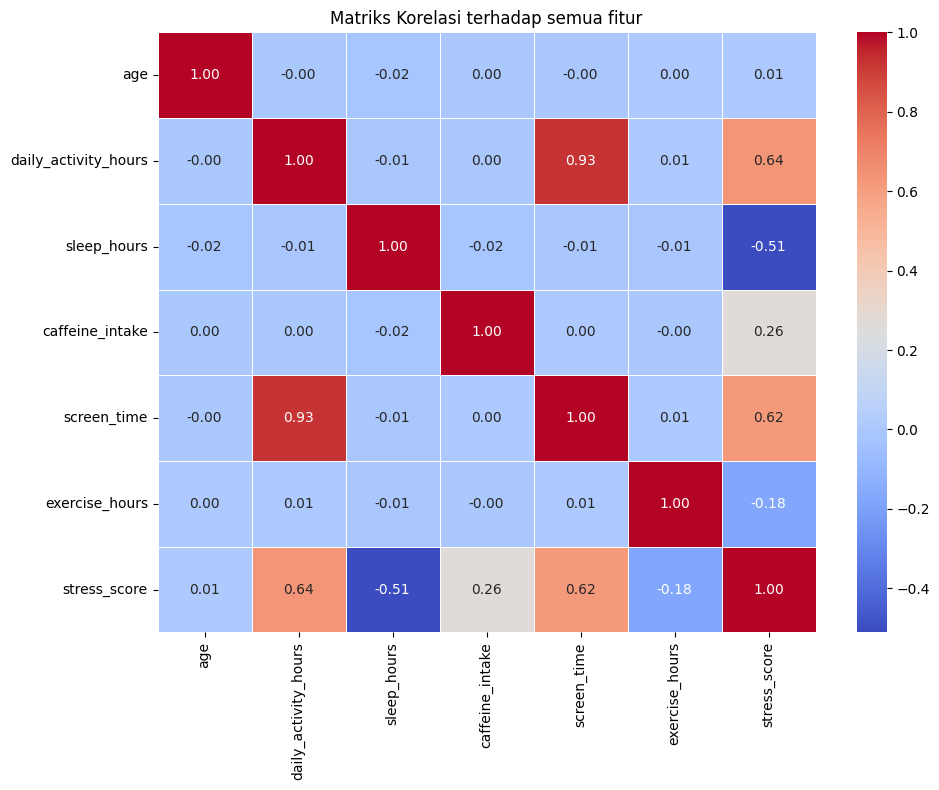

Faktor yang memiliki korelasi kuat (|r| > 0.5) dengan Stress Score:
daily_activity_hours    0.639728
sleep_hours            -0.511021
screen_time             0.617526
stress_score            1.000000
Name: stress_score, dtype: float64


In [91]:
# 1. Pilih kolom operasional/gaya hidup + stress_score untuk matriks korelasi
kolom_analisis = ['daily_activity_hours', 'sleep_hours', 'exercise_hours',
                  'caffeine_intake', 'screen_time', 'stress_score']
if 'work_setup_numeric' in df_clean.columns:
    kolom_analisis.append('work_setup_numeric')

correlation_matrix = df_clean[kolom_analisis].corr()

# 2. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5)
plt.title('Matriks Korelasi terhadap semua fitur')
plt.tight_layout()
plt.show()

# 3. Filter yang r > 0.5 (atau r < -0.5 untuk korelasi negatif kuat seperti jam tidur)
korelasi_kuat = correlation_matrix['stress_score'][abs(correlation_matrix['stress_score']) > 0.5]
print("Faktor yang memiliki korelasi kuat (|r| > 0.5) dengan Stress Score:")
print(korelasi_kuat)

In [92]:
fitur_analisis = ['daily_activity_hours', 'sleep_hours',
                  'exercise_hours', 'screen_time', 'caffeine_intake']

cross_check = df_clean.groupby('burnout_general')[fitur_analisis]\
                      .mean()\
                      .reindex(['Low', 'Medium', 'High'])\
                      .round(2)

print("Rata-rata Fitur Universal per Burnout Level:")
print(cross_check)

Rata-rata Fitur Universal per Burnout Level:
                 daily_activity_hours  sleep_hours  exercise_hours  \
burnout_general                                                      
Low                              7.03         7.42            1.10   
Medium                           9.63         6.07            0.99   
High                            12.55         5.45            0.80   

                 screen_time  caffeine_intake  
burnout_general                                
Low                     9.91             3.00  
Medium                 12.69             3.66  
High                   15.53             4.89  


In [93]:
#skewness data general


skewness = df_clean.select_dtypes(include='number').skew().round(3)
print(skewness)


print("\n")
for col, val in skewness.items():
    if abs(val) < 0.5:
        print(f"{col}: Normal ({val})")
    elif abs(val) < 1:
        print(f"{col}: Skew Sedang ({val})")
    else:
        print(f"{col}: Skew Tinggi ({val})")

age                    -0.030
daily_activity_hours    0.018
sleep_hours             0.033
caffeine_intake        -0.018
screen_time            -0.009
exercise_hours         -0.032
stress_score            0.113
dtype: float64


age: Normal (-0.03)
daily_activity_hours: Normal (0.018)
sleep_hours: Normal (0.033)
caffeine_intake: Normal (-0.018)
screen_time: Normal (-0.009)
exercise_hours: Normal (-0.032)
stress_score: Normal (0.113)


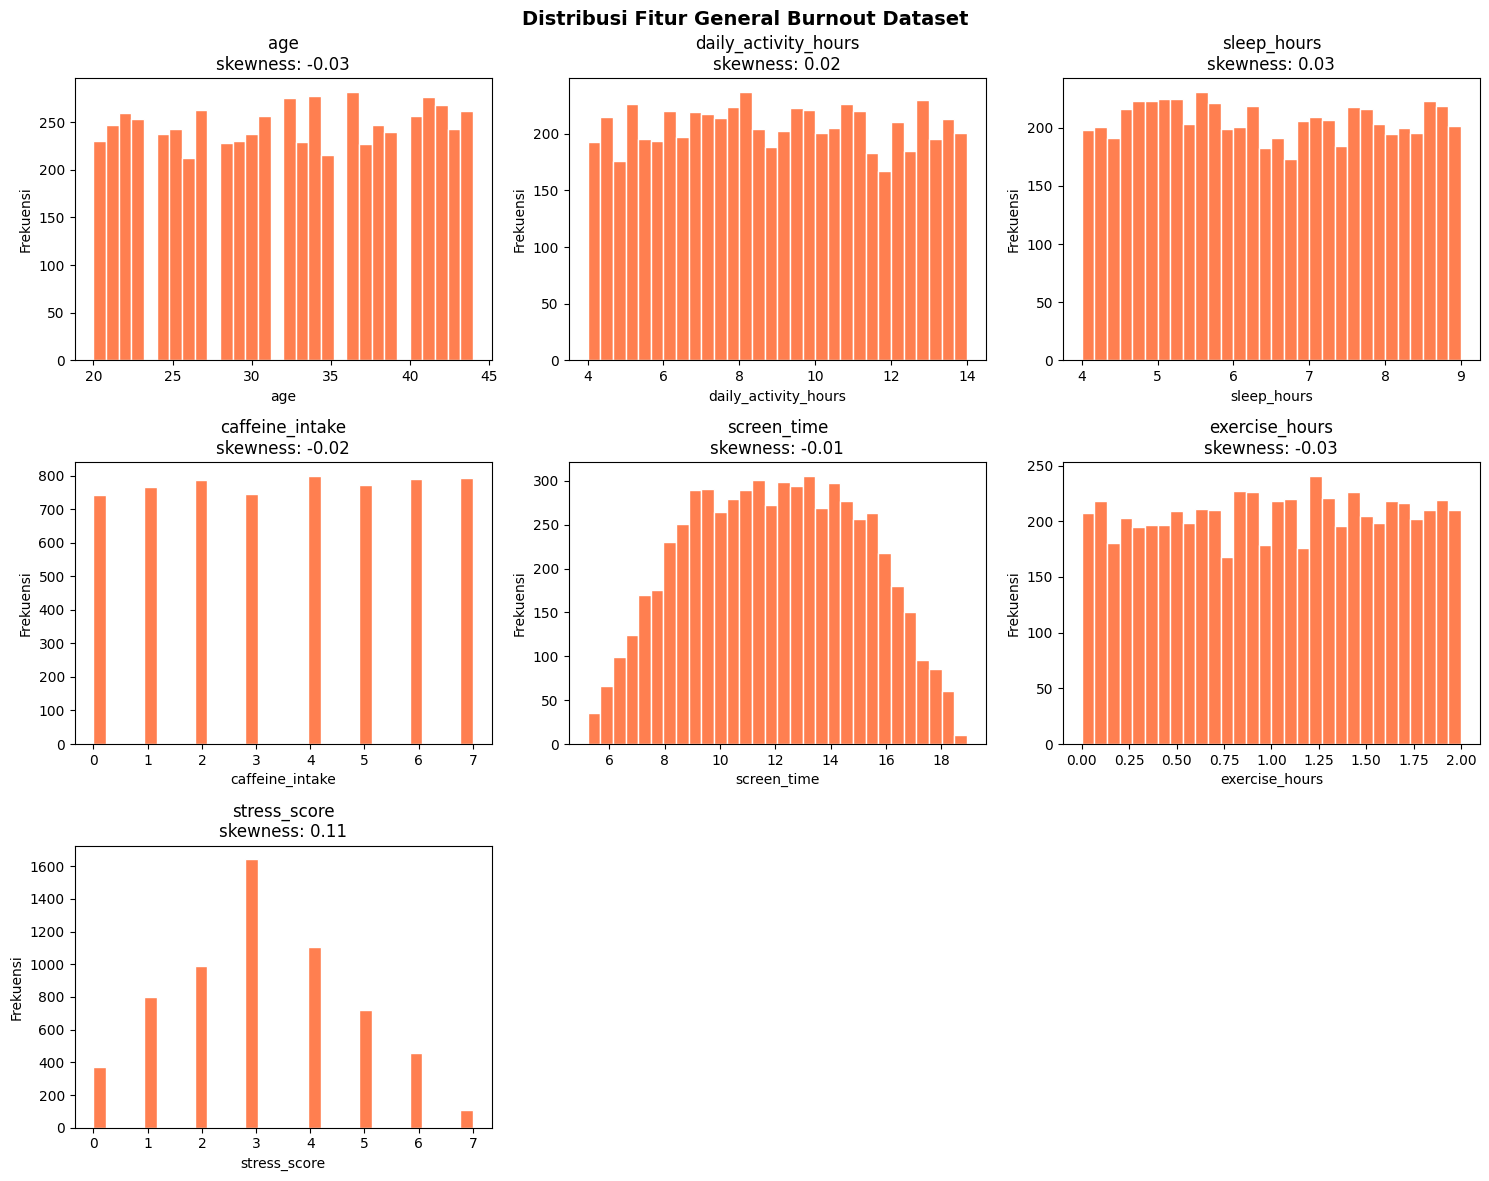

In [94]:
fitur_numerik = df_clean.select_dtypes(include='number').columns.tolist()
n_cols = 3
n_rows = (len(fitur_numerik) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(fitur_numerik):
    axes[i].hist(df_clean[col], bins=30,color='coral',edgecolor='white')
    axes[i].set_title(f'{col}\nskewness: {df_clean[col].skew():.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur General Burnout Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## EDA Pertanyaan

In [95]:
# Pertanyaan 1
fitur_universal = ['daily_activity_hours', 'sleep_hours',
                   'exercise_hours']

korelasi = df_clean[fitur_universal + ['stress_score']]\
           .corr()['stress_score']\
           .drop('stress_score')\
           .sort_values(ascending=False)\
           .round(3)

print("Korelasi Fitur data Dengan Stress Score")
print(korelasi)
faktor_tertinggi=korelasi.abs().idxmax()
nilai_tertinggi =korelasi.abs().max()
print(f"Faktor dengan korelasi tertinggi: '{faktor_tertinggi}' (r = {nilai_tertinggi:.3f})")

Korelasi Fitur data Dengan Stress Score
daily_activity_hours    0.640
exercise_hours         -0.176
sleep_hours            -0.511
Name: stress_score, dtype: float64
Faktor dengan korelasi tertinggi: 'daily_activity_hours' (r = 0.640)


In [96]:
# pertanyaan 2

bins_umur   = [0, 17, 25, 40, 100]
labels_umur = ['Remaja (<17)', 'Muda (18-25)', 'Dewasa (26-40)', 'Tua (41+)']

df_clean['age_group'] = pd.cut(df_clean['age'],bins=bins_umur,labels=labels_umur)
summary_umur = df_clean.groupby('age_group', observed=True)['stress_score']\
                       .agg(['mean', 'median', 'std', 'count'])\
                       .round(3)

print("Rata-rata Stress Score Tiap Kategori Umur")
print(summary_umur)

Rata-rata Stress Score Tiap Kategori Umur
                 mean  median    std  count
age_group                                  
Muda (18-25)    3.109     3.0  1.677   1471
Dewasa (26-40)  3.097     3.0  1.674   3680
Tua (41+)       3.116     3.0  1.655   1050


# Visualisasi

## Visualisasi Untuk Menjawab Pertanyaan

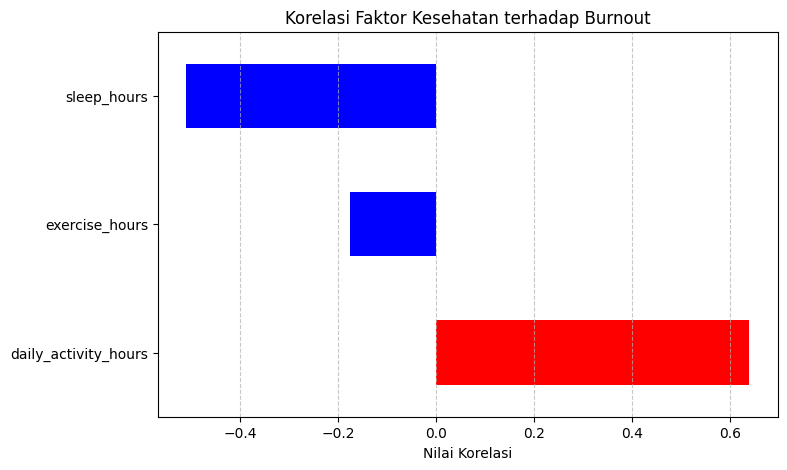

In [97]:
#Pertanyaan 1
plt.figure(figsize=(8, 5))

korelasi.plot(
    kind='barh',
    color=['red' if x >0 else 'blue' for x in korelasi]
)

plt.title('Korelasi Faktor Kesehatan terhadap Burnout')
plt.xlabel('Nilai Korelasi')

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

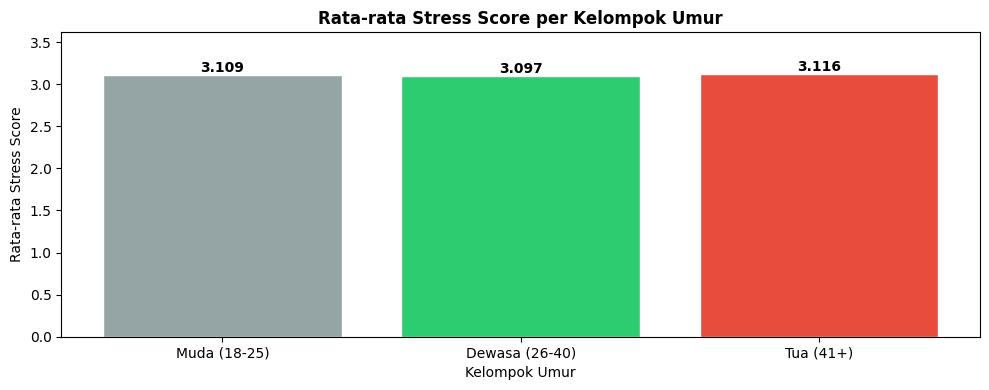

In [98]:
# Pertanyaan 2
cat  = summary_umur.index.tolist()
means  = summary_umur['mean']

tertinggi = means.idxmax()
terendah  = means.idxmin()

colors = ['#e74c3c' if i == tertinggi else '#2ecc71' if i == terendah
          else '#95a5a6' for i in cat]

plt.figure(figsize=(10, 4))
bars = plt.bar(cat, means, color=colors, edgecolor='white')

for bar, val in zip(bars, means):
    plt.annotate(f'{val:.3f}',
                 (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom', fontweight='bold')

plt.title('Rata-rata Stress Score per Kelompok Umur', fontweight='bold')
plt.xlabel('Kelompok Umur')
plt.ylabel('Rata-rata Stress Score')
plt.ylim(0, means.max() + 0.5)
plt.tight_layout()
plt.show()

## Visualisasi Tambahan untuk Menambah insight

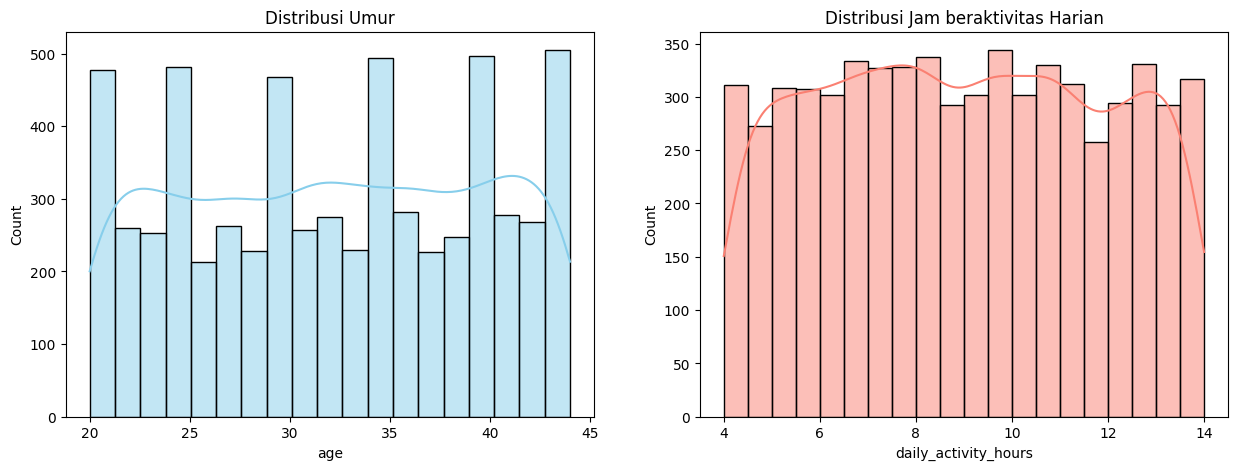

In [99]:
# Grafik yang menggambarkan distribusi umur dan jam aktivitasnya
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Umur')
sns.histplot(df_clean['daily_activity_hours'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Jam beraktivitas Harian')

plt.show()

/tmp/ipykernel_1515/230388300.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='burnout_general', order=order,


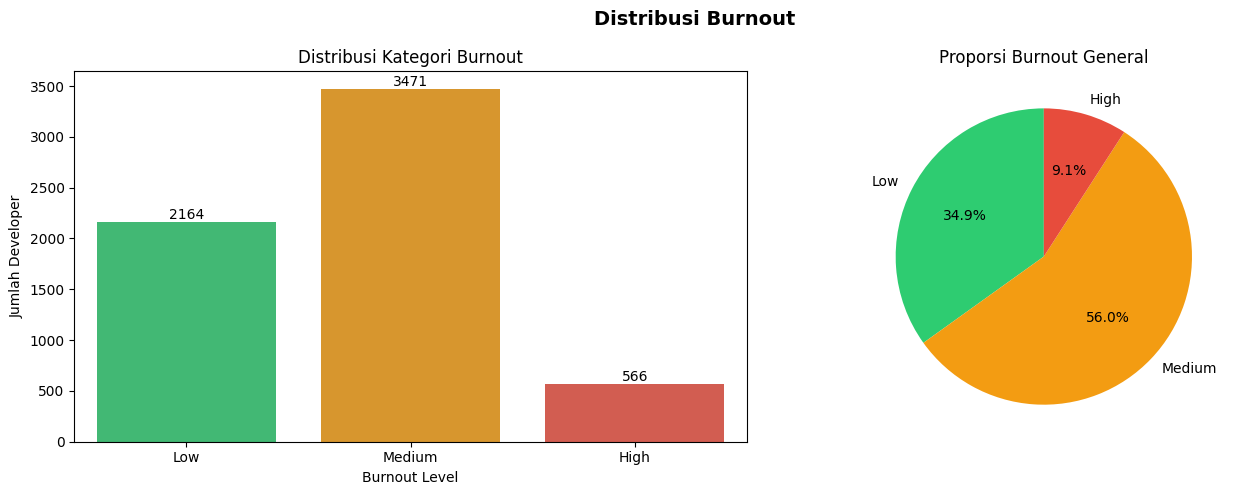

In [100]:
# Distribusi Burnout General
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Low', 'Medium', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Countplot
sns.countplot(data=df_clean, x='burnout_general', order=order,
              palette=colors, ax=axes[0])
axes[0].set_title('Distribusi Kategori Burnout')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Jumlah Developer')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Pie chart
counts = df_clean['burnout_general'].value_counts().reindex(order)
axes[1].pie(counts, labels=order, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporsi Burnout General')

plt.suptitle('Distribusi Burnout', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

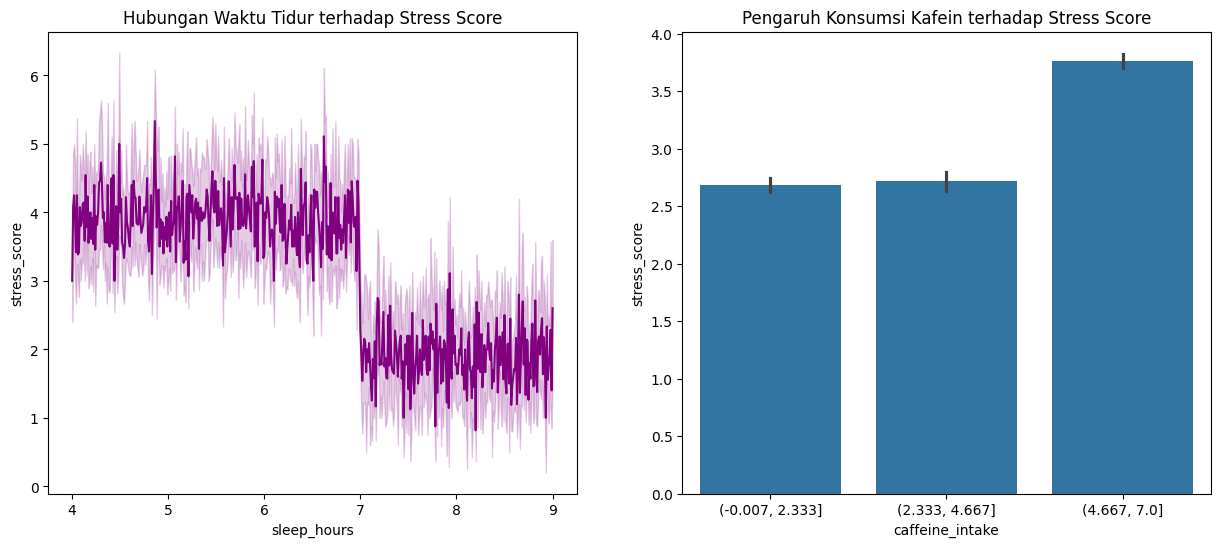

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tidur vs Stres
sns.lineplot(data=df_clean, x='sleep_hours', y='stress_score', ax=axes[0], color='purple')
axes[0].set_title('Hubungan Waktu Tidur terhadap Stress Score')

# Kafein vs Stres
sns.barplot(data=df_clean, x=pd.cut(df_clean['caffeine_intake'], bins=3), y='stress_score', ax=axes[1])
axes[1].set_title('Pengaruh Konsumsi Kafein terhadap Stress Score')

plt.show()

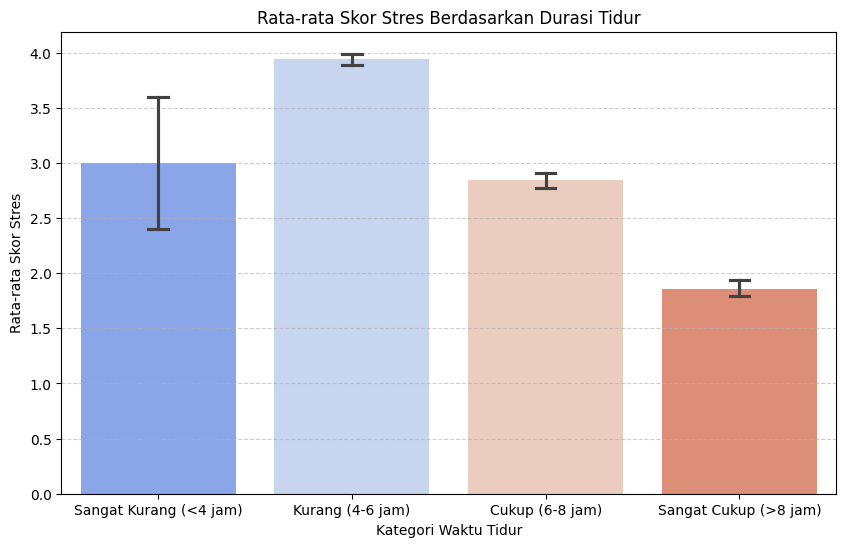

In [102]:
df_clean = df_clean.copy()

bins = [0, 4, 6, 8, 15]
labels = ['Sangat Kurang (<4 jam)', 'Kurang (4-6 jam)', 'Cukup (6-8 jam)', 'Sangat Cukup (>8 jam)']
df_clean.loc[:, 'sleep_category'] = pd.cut(df_clean['sleep_hours'], bins=bins, labels=labels)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x='sleep_category',
    y='stress_score',
    hue='sleep_category',
    palette='coolwarm',
    capsize=.1,
    legend=False
)

plt.title('Rata-rata Skor Stres Berdasarkan Durasi Tidur')
plt.xlabel('Kategori Waktu Tidur')
plt.ylabel('Rata-rata Skor Stres')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

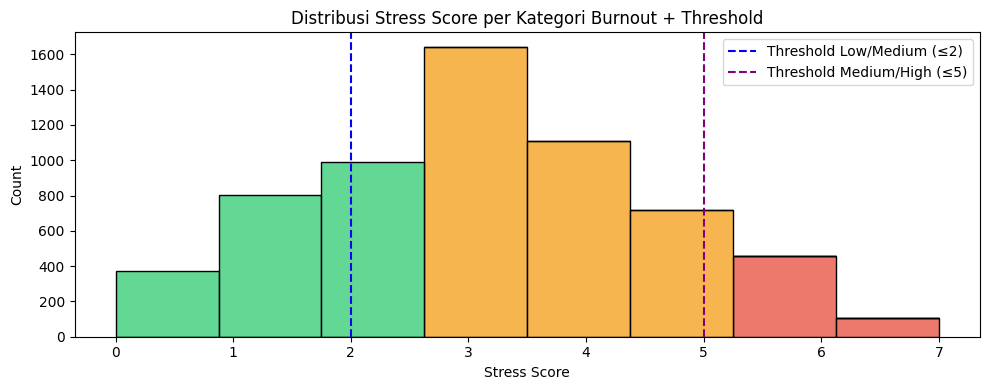

In [103]:
plt.figure(figsize=(10, 4))
sns.histplot(data=df_clean, x='stress_score', hue='burnout_general',
             hue_order=['Low', 'Medium', 'High'],
             palette=['#2ecc71', '#f39c12', '#e74c3c'],
             multiple='stack', bins=8)
plt.axvline(x=2, color='blue', linestyle='--', label='Threshold Low/Medium (≤2)')
plt.axvline(x=5, color='purple', linestyle='--', label='Threshold Medium/High (≤5)')
plt.title('Distribusi Stress Score per Kategori Burnout + Threshold')
plt.xlabel('Stress Score')
plt.legend()
plt.tight_layout()
plt.show()

# MACHINE LEARNING

In [104]:
# Cek imbalanced data
print("Jumlah sampel per kategori:")
print(df_clean['burnout_general'].value_counts())

Jumlah sampel per kategori:
burnout_general
Medium    3471
Low       2164
High       566
Name: count, dtype: int64


In [105]:
#Cek outlier data
fitur_cek = ['sleep_hours', 'exercise_hours', 'daily_activity_hours',
             'screen_time', 'caffeine_intake']

print("Deteksi Outlier (Metode IQR)\n")
for col in fitur_cek:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df_clean[(df_clean[col]<lower) |
                             (df_clean[col]>upper)].shape[0]

    print(f"{col}:")
    print(f"-Q1={Q1:.2f}, Q3={Q3:.2f},IQR={IQR:.2f}")
    print(f"-Batas bawah={lower:.2f}, Batas atas={upper:.2f}")
    print(f"-Jumlah outlier: {outlier_count} baris\n")

Deteksi Outlier (Metode IQR)

sleep_hours:
-Q1=5.22, Q3=7.75,IQR=2.53
-Batas bawah=1.42, Batas atas=11.54
-Jumlah outlier: 0 baris

exercise_hours:
-Q1=0.52, Q3=1.51,IQR=0.99
-Batas bawah=-0.96, Batas atas=3.00
-Jumlah outlier: 0 baris

daily_activity_hours:
-Q1=6.56, Q3=11.39,IQR=4.83
-Batas bawah=-0.69, Batas atas=18.64
-Jumlah outlier: 0 baris

screen_time:
-Q1=9.48, Q3=14.43,IQR=4.95
-Batas bawah=2.06, Batas atas=21.85
-Jumlah outlier: 0 baris

caffeine_intake:
-Q1=2.00, Q3=6.00,IQR=4.00
-Batas bawah=-4.00, Batas atas=12.00
-Jumlah outlier: 0 baris



Data tidak sepenuhnya seimbang, tapi tingkat ketimpanganya tidak ekstrem dan tidak terdeteksi adanya outlier yang disebabkan karena dataset yang digunakan sudah memiliki distribusi data yang rapih

In [106]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression


In [107]:
#Encode

fitur = ['daily_activity_hours', 'sleep_hours', 'exercise_hours',
         'screen_time', 'caffeine_intake', 'age']

X = df_clean[fitur]
y = df_clean['burnout_general']
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Low=0, Medium=1, High=2
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Data training :{X_train.shape[0]} baris")
print(f"Data testing  :{X_test.shape[0]} baris")
print(f"Kelas         :{le.classes_}")

Data training :4960 baris
Data testing  :1241 baris
Kelas         :['High' 'Low' 'Medium']


In [108]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest
Accuracy: 0.9967767929089444
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       113
           1       1.00      0.99      1.00       433
           2       1.00      1.00      1.00       695

    accuracy                           1.00      1241
   macro avg       1.00      1.00      1.00      1241
weighted avg       1.00      1.00      1.00      1241



In [109]:
# Logistic
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression
Accuracy: 0.8331990330378727
              precision    recall  f1-score   support

           0       0.73      0.61      0.67       113
           1       0.87      0.81      0.83       433
           2       0.83      0.89      0.86       695

    accuracy                           0.83      1241
   macro avg       0.81      0.77      0.79      1241
weighted avg       0.83      0.83      0.83      1241



In [110]:
hasil_model = {
    'Random Forest'      : {'model': rf, 'y_pred': pred_rf,
                            'accuracy': accuracy_score(y_test, pred_rf)},
    'Logistic Regression': {'model': lr, 'y_pred': pred_lr,
                            'accuracy': accuracy_score(y_test, pred_lr)}
}

/tmp/ipykernel_1515/343124958.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(8), x='Importance', y='Feature', palette='viridis')


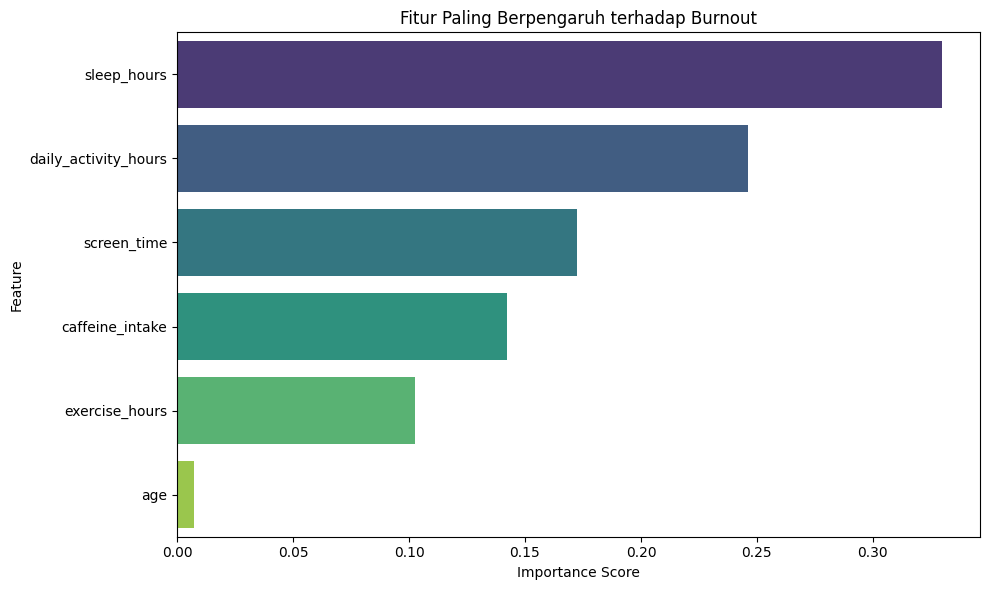

In [111]:
# Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.DataFrame({
    'Feature'   : fitur,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importances.head(8), x='Importance', y='Feature', palette='viridis')
plt.title('Fitur Paling Berpengaruh terhadap Burnout')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

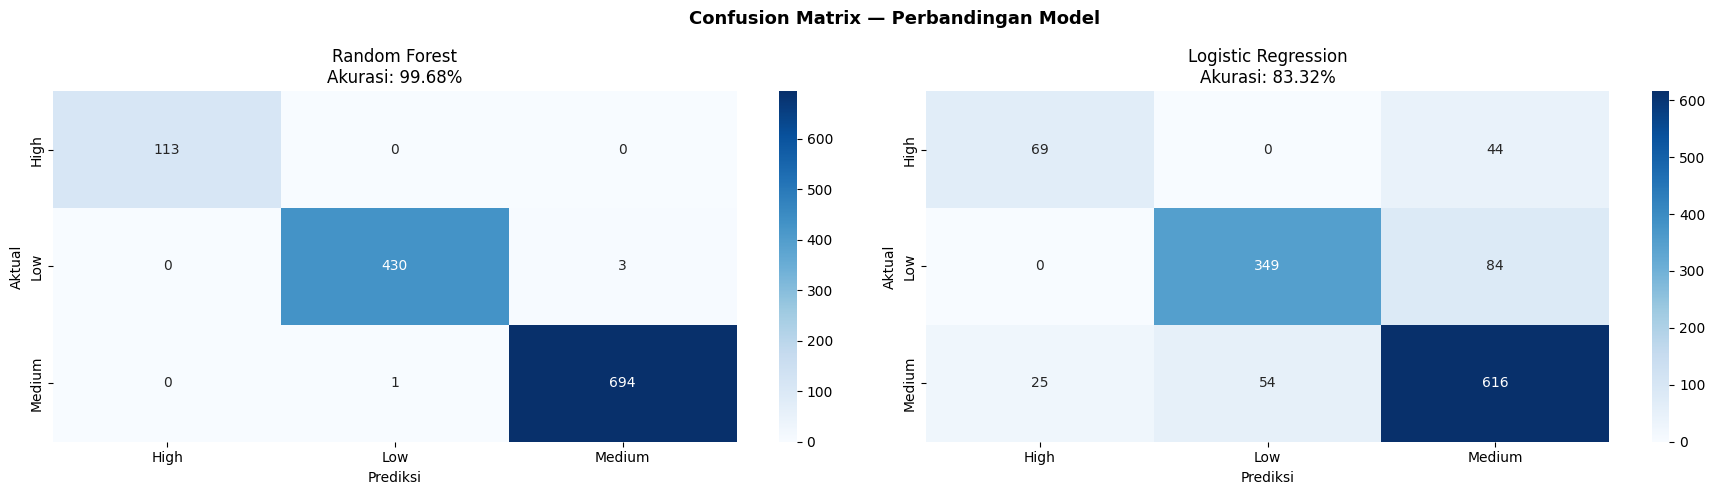

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i, (nama, hasil) in enumerate(hasil_model.items()):
    cm = confusion_matrix(y_test, hasil['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=axes[i])
    axes[i].set_title(f"{nama}\nAkurasi: {hasil['accuracy']*100:.2f}%")
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Perbandingan Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [113]:
from joblib import dump

best_name  = max(hasil_model, key=lambda x: hasil_model[x]['accuracy'])
best_model = hasil_model[best_name]['model']

print(f"\nModel terbaik: {best_name} ({hasil_model[best_name]['accuracy']*100:.2f}%)")
dump(best_model, 'burnout_model.joblib')
dump(le, 'label_encoder.joblib')


Model terbaik: Random Forest (99.68%)


['label_encoder.joblib']

In [114]:
dummy = pd.DataFrame([{
    'daily_activity_hours': 11,
    'sleep_hours'         : 5,
    'exercise_hours'      : 0.2,
    'screen_time'         : 13,
    'caffeine_intake'     : 5,
    'age'                 : 28,
}])
prediksi_encoded = rf.predict(dummy)
prediksi_label   = le.inverse_transform(prediksi_encoded)
prediksi_proba   = rf.predict_proba(dummy)

print("Hasil Prediksi Data Dummy")
print(f"Input:")
for col, val in dummy.iloc[0].items():
    print(f"{col:25s}: {val}")
print(f"\nHasil Prediksi: {prediksi_label[0]}")


Hasil Prediksi Data Dummy
Input:
daily_activity_hours     : 11.0
sleep_hours              : 5.0
exercise_hours           : 0.2
screen_time              : 13.0
caffeine_intake          : 5.0
age                      : 28.0

Hasil Prediksi: Medium


Untuk insight tambahan kami buat di laporan teknikal
